## Problem 1

 ### a: Creating a Scatter Plot

   eruptions  waiting
0      3.600       79
1      1.800       54
2      3.333       74
3      2.283       62
4      4.533       85


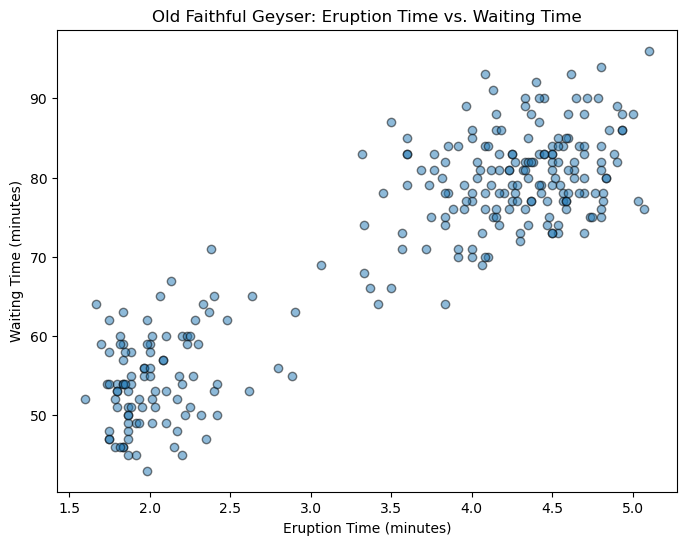

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('./faithful.csv')

# Display the first few rows to understand the structure
print(data.head())

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['eruptions'], data['waiting'], alpha=0.5, edgecolor='k')
plt.title('Old Faithful Geyser: Eruption Time vs. Waiting Time')
plt.xlabel('Eruption Time (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.show()


### b: How many clusters do you see based on your scatter plot? For the purposes of this question, a cluster is a “blob” of many data points that are close together, with regions of fewer data points between it and other “blobs”/clusters.

Observations
Looking at the plot:

Clusters Identification:

We can observe two main clusters:
One cluster appears around shorter eruption times (1.5 to 3 minutes) and shorter waiting times (about 50 to 70 minutes).
Another cluster is centered around longer eruption times (3.5 to 5 minutes) and longer waiting times (about 70 to 90 minutes).
Cluster Count:

Based on this visualization, we can determine that there are 2 clusters.

### c: Describe the steps of a hierarchical clustering algorithm. Based on your scatter plot, would this method be appropriate for this dataset?

## Problem 2: Implementing the K-Means Algorithm

### a: Step 1: Implement the K-Means Algorithm

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('./faithful.csv')

# Convert data to numpy array (ignore the first column if it contains instance IDs)
X = data[['eruptions', 'waiting']].values

# K-Means function
def kmeans(X, k, max_iters=100):
    # Randomly initialize centroids by selecting k random points from X
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    prev_centroids = centroids + 1  # ensure initial difference
    objective_values = []
    
    # Run the algorithm until convergence or max_iters
    for i in range(max_iters):
        # Step 1: Assign clusters
        distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
        labels = np.argmin(distances, axis=0)
        
        # Step 2: Update centroids
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        
        # Calculate the objective function (sum of squared distances to centroids)
        objective = sum(np.min(distances, axis=0)**2)
        objective_values.append(objective)
        
        # Check for convergence (if centroids do not change)
        if np.all(new_centroids == centroids):
            break
        centroids = new_centroids
    
    return labels, centroids, objective_values

# Run K-Means with k=2 (based on Problem 1's conclusion)
k = 2
labels, centroids, objective_values = kmeans(X, k)


### b: Plot the Clustering Results

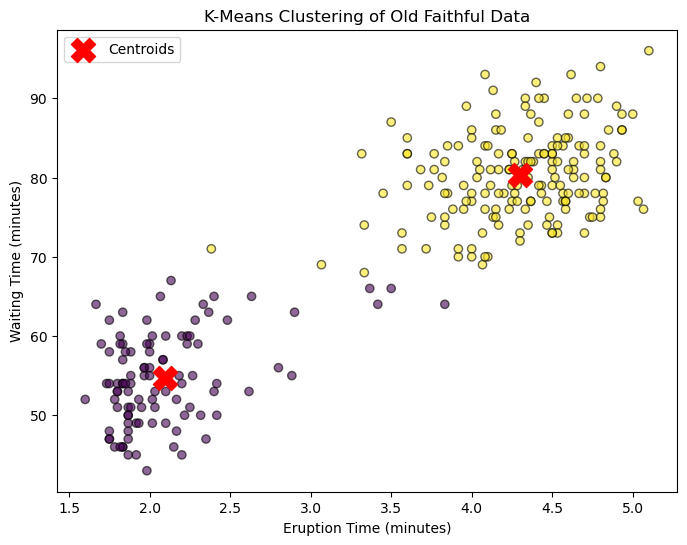

In [26]:
# Scatter plot of the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', alpha=0.6, edgecolor='k')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering of Old Faithful Data')
plt.xlabel('Eruption Time (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.legend()
plt.show()

#### Analysis of Results

#### Scatter Plot with K-Means Clustering

1. **Cluster Separation**: The K-Means algorithm has successfully separated the data into two clusters, as identified in Problem 1.
   - The two clusters correspond to points grouped around short and long eruption times, with respective waiting times.
2. **Centroids**: The red 'X' marks the centroids of each cluster. The centroids appear well-positioned at the center of each cluster, confirming that the algorithm has effectively identified the cluster centers.

### c: Plot the Objective Function vs. Iterations

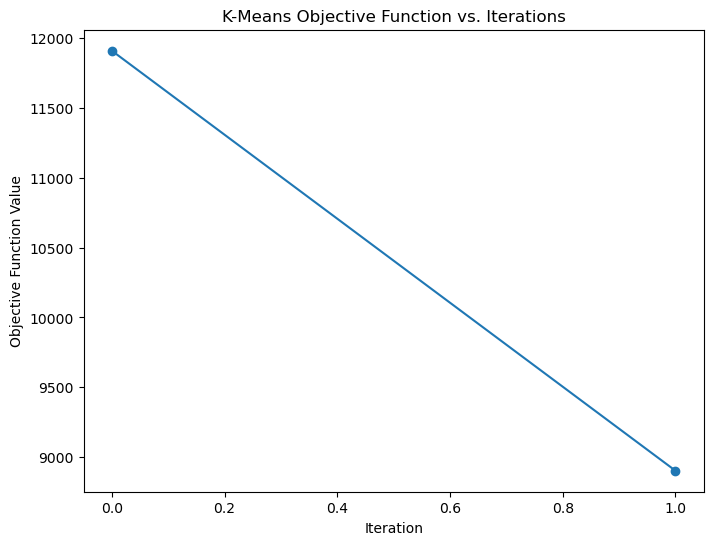

In [31]:
# Plot the objective function to observe convergence
plt.figure(figsize=(8, 6))
plt.plot(objective_values, marker='o')
plt.title('K-Means Objective Function vs. Iterations')
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.show()

#### Objective Function Plot

1. **Objective Function Convergence**: The objective function (sum of squared distances from points to their respective centroids) shows a decrease across iterations.
2. **Convergence Speed**: Since the plot shows a sharp drop in just one iteration, the K-Means algorithm has converged quickly. This could be due to the initial centroids being close to the optimal positions, reducing the number of adjustments needed.

### d: Did the method manage to find the clusters that you identified in Problem 1? If not, did it help to run the method again with another random initialization?

**Did the K-Means Algorithm Identify the Clusters Correctly?**: Yes, the algorithm successfully identified the two clusters, aligning with our visual observation in Problem 1.

**Further Initialization Attempts**: Given that the clusters were correctly identified, further random initializations may not be necessary unless observe inconsistent results in different runs.